<a href="https://colab.research.google.com/github/poornasainehal1781/23CSBTB28/blob/main/HPC__PROJECT_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# =========================
# 1. INSTALL & IMPORT LIBRARIES
# =========================

!pip -q install pandas numpy matplotlib seaborn scikit-learn joblib tqdm

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from joblib import Parallel, delayed, cpu_count
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

print("CPU cores available:", cpu_count())

CPU cores available: 2


In [8]:
# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv("/content/netflix_titles.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [9]:
# =========================
# 3. PREPROCESSING
# =========================

data = df.copy()

data["director"] = data["director"].fillna("Unknown")
data["cast"] = data["cast"].fillna("Unknown")
data["country"] = data["country"].fillna("Unknown")
data["rating"] = data["rating"].fillna("Unknown")
data["duration"] = data["duration"].fillna("0 min")
data["date_added"] = data["date_added"].fillna("January 1, 2000")
data["listed_in"] = data["listed_in"].fillna("Unknown")
data["description"] = data["description"].fillna("")

data["date_added"] = pd.to_datetime(data["date_added"], errors="coerce")
data["year_added"] = data["date_added"].dt.year.fillna(2000).astype(int)
data["month_added"] = data["date_added"].dt.month.fillna(1).astype(int)

le = LabelEncoder()
data["type_encoded"] = le.fit_transform(data["type"])

def extract_duration(x):
    try:
        return int(str(x).split()[0])
    except:
        return 0

data["duration_num"] = data["duration"].apply(extract_duration)

data["title_len"] = data["title"].astype(str).apply(len)
data["desc_len"] = data["description"].astype(str).apply(len)
data["num_cast"] = data["cast"].astype(str).apply(lambda x: len(x.split(",")) if x != "Unknown" else 0)
data["num_categories"] = data["listed_in"].astype(str).apply(lambda x: len(x.split(",")))

processed = data[[
    "show_id", "type_encoded", "release_year", "duration_num",
    "title_len", "desc_len", "num_cast", "num_categories",
    "year_added", "month_added"
]].copy()

print("Processed Shape:", processed.shape)
display(processed.head())

Processed Shape: (8807, 10)


,show_id,type_encoded,release_year,duration_num,title_len,desc_len,num_cast,num_categories,year_added,month_added
0,s1,0,2020,90,20,152,0,1,2021,9
1,s2,1,2021,2,13,147,19,3,2021,9
2,s3,1,2021,1,9,146,9,3,2021,9
3,s4,1,2021,1,21,147,0,2,2021,9
4,s5,1,2021,2,12,152,8,3,2021,9


In [10]:
# =========================
# 4. HEAVY COMPUTATION
# =========================

def compute_task(row):
    x1 = row["type_encoded"]
    x2 = row["release_year"]
    x3 = row["duration_num"]
    x4 = row["title_len"]
    x5 = row["desc_len"]
    x6 = row["num_cast"]
    x7 = row["num_categories"]
    x8 = row["year_added"]
    x9 = row["month_added"]

    val = 0.0

    # HEAVY LOOP → parallel should outperform serial
    for i in range(1, 20000):
        val += (
            math.sin(x2 * i * 0.0001)
            + math.cos(x3 + i * 0.0002)
            + math.sqrt(abs(x4 * x5 + i))
            + math.log1p(abs(x6 + x7 + x8 + x9 + i))
        ) / (i + 1)

    return {
        "show_id": row["show_id"],
        "score": val
    }

print("Heavy computation function ready.")

Heavy computation function ready.


In [11]:
# =========================
# 5. SERIAL EXECUTION
# =========================

def run_serial(df_input):
    start = time.time()

    results = []
    for _, row in tqdm(df_input.iterrows(), total=len(df_input), desc="Serial"):
        results.append(compute_task(row))

    end = time.time()
    return pd.DataFrame(results), end - start

serial_results, serial_time = run_serial(processed)

print("Serial Time:", serial_time)
display(serial_results.head())

Serial: 100%|██████████| 8807/8807 [01:17<00:00, 113.07it/s]

Serial Time: 77.88940238952637


,show_id,score
0,s1,719.157461
1,s2,627.197428
2,s3,576.239170
3,s4,730.037715
4,s5,619.210696


In [12]:
# =========================
# 6. PARALLEL EXECUTION
# =========================

def run_parallel(df_input):
    start = time.time()

    rows = [row for _, row in df_input.iterrows()]

    results = Parallel(n_jobs=-1)(
        delayed(compute_task)(row) for row in tqdm(rows, desc="Parallel")
    )

    end = time.time()
    return pd.DataFrame(results), end - start

parallel_results, parallel_time = run_parallel(processed)

print("Parallel Time:", parallel_time)
display(parallel_results.head())

Parallel: 100%|██████████| 8807/8807 [01:09<00:00, 126.14it/s]


Parallel Time: 71.19251203536987


,show_id,score
0,s1,719.157461
1,s2,627.197428
2,s3,576.239170
3,s4,730.037715
4,s5,619.210696


In [13]:
# =========================
# 7. VALIDATION
# =========================

merged = serial_results.merge(parallel_results, on="show_id", suffixes=("_s", "_p"))

mse = mean_squared_error(merged["score_s"], merged["score_p"])
mae = mean_absolute_error(merged["score_s"], merged["score_p"])

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.0
MAE: 0.0


In [14]:
# =========================
# 8. PERFORMANCE METRICS
# =========================

num_cores = cpu_count()
dataset_size = len(processed)

speedup = serial_time / parallel_time
efficiency = speedup / num_cores

serial_throughput = dataset_size / serial_time
parallel_throughput = dataset_size / parallel_time

metrics_df = pd.DataFrame({
    "Metric": [
        "Dataset Size",
        "CPU Cores Used",
        "Serial Execution Time (s)",
        "Parallel Execution Time (s)",
        "Speedup",
        "Efficiency",
        "Serial Throughput (rows/s)",
        "Parallel Throughput (rows/s)",
        "MSE",
        "MAE"
    ],
    "Value": [
        dataset_size,
        num_cores,
        round(serial_time, 4),
        round(parallel_time, 4),
        round(speedup, 4),
        round(efficiency, 4),
        round(serial_throughput, 2),
        round(parallel_throughput, 2),
        mse,
        mae
    ]
})

display(metrics_df)

,Metric,Value
0,Dataset Size,8807.0000
1,CPU Cores Used,2.0000
2,Serial Execution Time (s),77.8894
3,Parallel Execution Time (s),71.1925
4,Speedup,1.0941
5,Efficiency,0.5470
6,Serial Throughput (rows/s),113.0700
7,Parallel Throughput (rows/s),123.7100
8,MSE,0.0000
9,MAE,0.0000


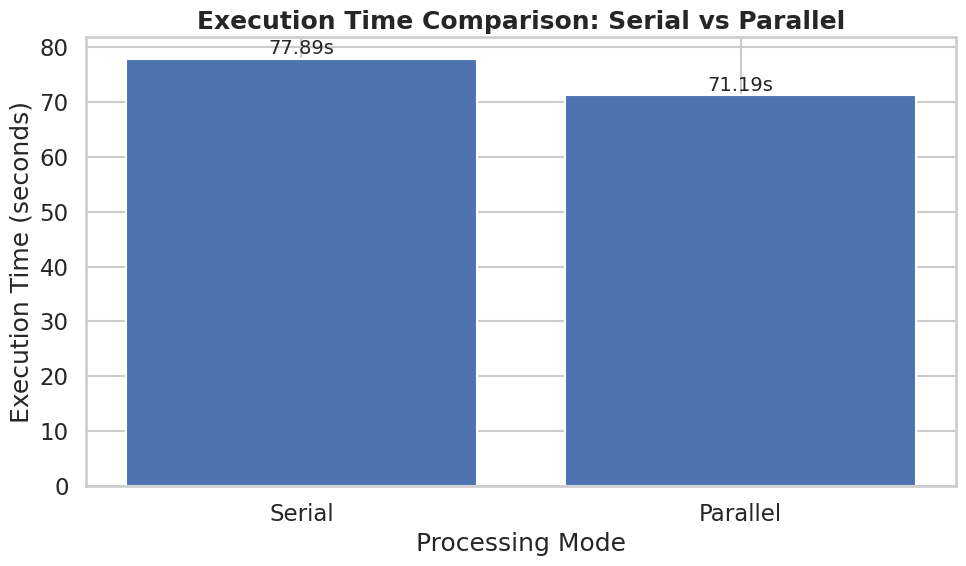

In [15]:
# =========================
# 9. EXECUTION TIME GRAPH
# =========================

plt.figure(figsize=(10,6))
bars = plt.bar(["Serial", "Parallel"], [serial_time, parallel_time])

plt.title("Execution Time Comparison: Serial vs Parallel", fontsize=18, fontweight="bold")
plt.ylabel("Execution Time (seconds)")
plt.xlabel("Processing Mode")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.1, f"{height:.2f}s",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

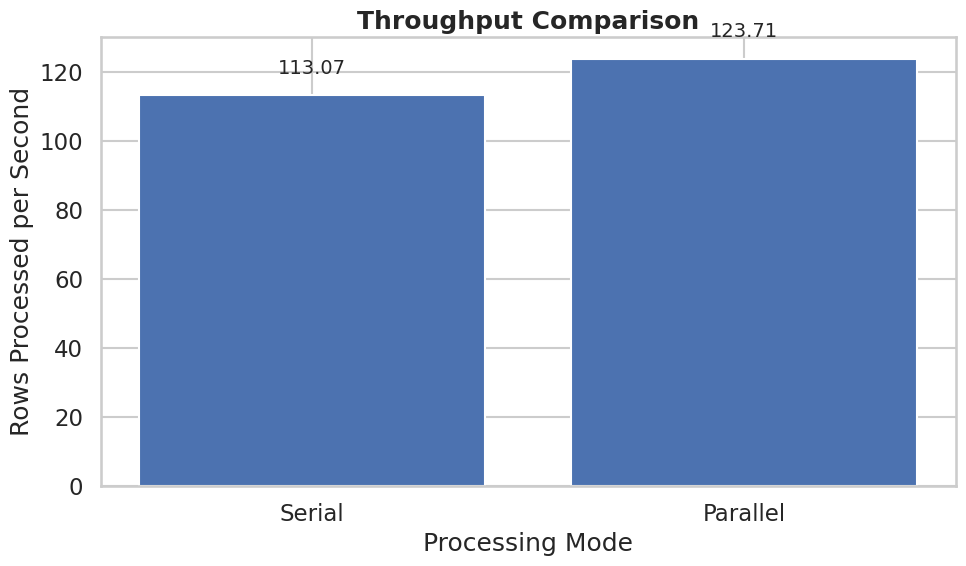

In [16]:
# =========================
# 10. THROUGHPUT GRAPH
# =========================

plt.figure(figsize=(10,6))
bars = plt.bar(["Serial", "Parallel"], [serial_throughput, parallel_throughput])

plt.title("Throughput Comparison", fontsize=18, fontweight="bold")
plt.ylabel("Rows Processed per Second")
plt.xlabel("Processing Mode")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f"{height:.2f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

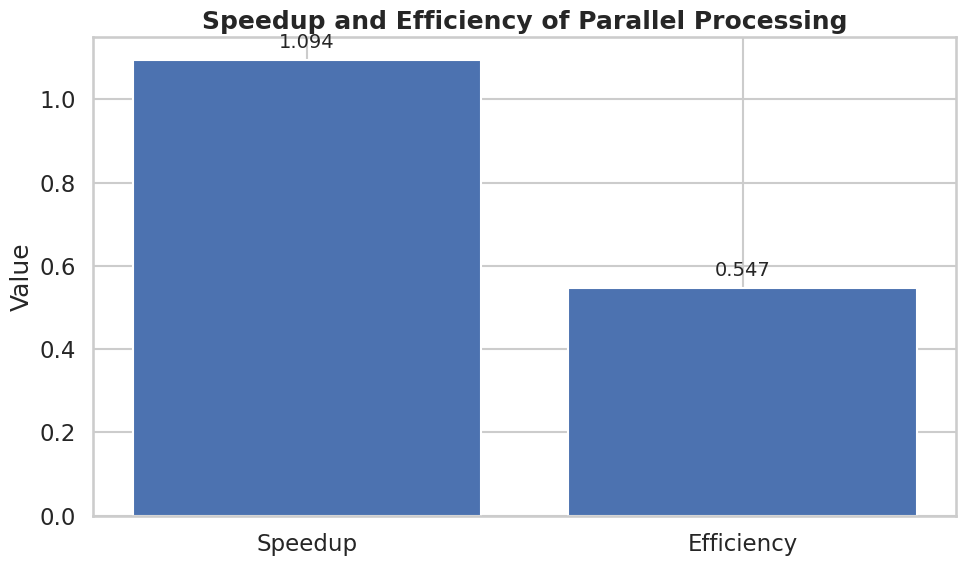

In [17]:
# =========================
# 11. SPEEDUP & EFFICIENCY GRAPH
# =========================

perf_summary = pd.DataFrame({
    "Metric": ["Speedup", "Efficiency"],
    "Value": [speedup, efficiency]
})

plt.figure(figsize=(10,6))
bars = plt.bar(perf_summary["Metric"], perf_summary["Value"])

plt.title("Speedup and Efficiency of Parallel Processing", fontsize=18, fontweight="bold")
plt.ylabel("Value")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f"{height:.3f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()

In [18]:
# =========================
# 12. FINAL SUMMARY
# =========================

print("=" * 60)
print("FINAL PERFORMANCE COMPARISON REPORT")
print("=" * 60)

print(f"Dataset Used              : Netflix Titles (Kaggle)")
print(f"Total Records Processed   : {dataset_size}")
print(f"CPU Cores Available       : {num_cores}")
print(f"Serial Time               : {serial_time:.4f} seconds")
print(f"Parallel Time             : {parallel_time:.4f} seconds")
print(f"Speedup                   : {speedup:.4f}x")
print(f"Efficiency                : {efficiency:.4f}")
print(f"Serial Throughput         : {serial_throughput:.2f} rows/sec")
print(f"Parallel Throughput       : {parallel_throughput:.2f} rows/sec")
print(f"MSE                       : {mse:.12f}")
print(f"MAE                       : {mae:.12f}")

print("\nConclusion:")
if serial_time > parallel_time:
    print("Parallel processing outperformed serial processing for this CPU-intensive workload.")
else:
    print("Serial processing outperformed parallel processing in this environment.")

FINAL PERFORMANCE COMPARISON REPORT
Dataset Used              : Netflix Titles (Kaggle)
Total Records Processed   : 8807
CPU Cores Available       : 2
Serial Time               : 77.8894 seconds
Parallel Time             : 71.1925 seconds
Speedup                   : 1.0941x
Efficiency                : 0.5470
Serial Throughput         : 113.07 rows/sec
Parallel Throughput       : 123.71 rows/sec
MSE                       : 0.000000000000
MAE                       : 0.000000000000

Conclusion:
Parallel processing outperformed serial processing for this CPU-intensive workload.


In [19]:
# =========================
# 13. EXPORT RESULTS (OPTIONAL)
# =========================

metrics_df.to_csv("performance_metrics.csv", index=False)
merged.to_csv("serial_vs_parallel_output_comparison.csv", index=False)

print("Files saved successfully:")
print("- performance_metrics.csv")
print("- serial_vs_parallel_output_comparison.csv")

Files saved successfully:
- performance_metrics.csv
- serial_vs_parallel_output_comparison.csv
